https://wikidocs.net/37406

In [3]:
import math
import torch
import matplotlib.pyplot as plt

In [ ]:
conda install pytorch torchvision torchaudio cpuonly -c pytorch

In [5]:
# 학습용 데이터
x = torch.linspace(-math.pi, math.pi, 1000)
# 정답
y = torch.sin(x)

In [18]:
# 3차 다항식 (sin함수 예측)
# f(x) = ax**3 + bx**2 + cx + d  (a,b,c -> 가중치 weight / d -> 절편 bias)
# a,b,c,d 를 초기화 
a, b, c, d = torch.randn(()),torch.randn(()),torch.randn(()),torch.randn(())
y_random = a*x**3 + b*x**2 + c*x + d

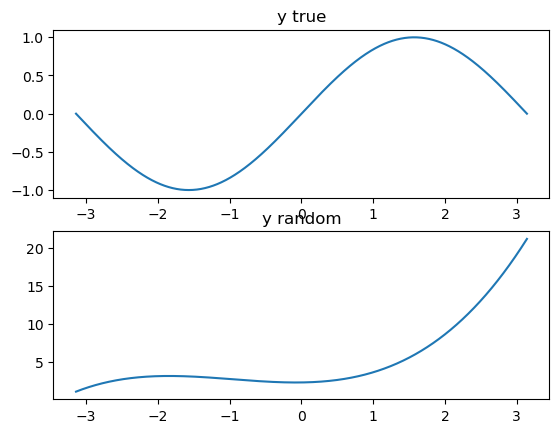

In [19]:
# 시각화
# 1. 실제값 시각화
plt.subplot(2,1,1)
plt.title('y true')
plt.plot(x,y)

plt.subplot(2,1,2)
plt.title ('y random')
plt.plot(x,y_random)
# 2. 임의의 가중치로 만든 예측용 값으로 시각화
plt.show()

epoch  1 : loss  0.0579058937728405
epoch  101 : loss  0.0579058937728405
epoch  201 : loss  0.0579058937728405
epoch  301 : loss  0.0579058937728405
epoch  401 : loss  0.0579058937728405
epoch  501 : loss  0.0579058937728405
epoch  601 : loss  0.0579058937728405
epoch  701 : loss  0.0579058937728405
epoch  801 : loss  0.0579058937728405
epoch  901 : loss  0.0579058937728405
epoch  1001 : loss  0.0579058937728405
epoch  1101 : loss  0.0579058937728405
epoch  1201 : loss  0.0579058937728405
epoch  1301 : loss  0.0579058937728405
epoch  1401 : loss  0.0579058937728405
epoch  1501 : loss  0.0579058937728405
epoch  1601 : loss  0.0579058937728405
epoch  1701 : loss  0.0579058937728405
epoch  1801 : loss  0.0579058937728405
epoch  1901 : loss  0.0579058937728405


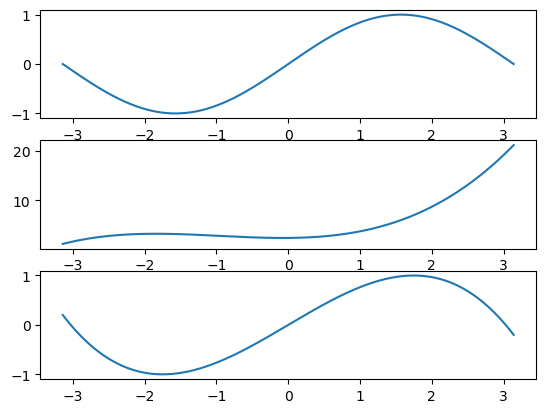

In [ ]:
# 기울기 = lost가 커지나거 작아지는 방향을 알려주는 화살표

# a,b,c,d 를 어떻게 바꿔야 loss가 줄어드는지 알아야함. --> 이 정보를 gradient가 알려줌.

# 파라미터 정의
learning_rate = 1e-6
total_loss = []
for epoch in range(2000):
    # forward : 3차원 방정식에 x값을 넣고, abcd를 넣고 예측
    y_pred = a*x**3 + b*x**2 + c*x + d  #모델
    

# loss 손실 정의 
    # 오차를 제곱하는 이유 : 
        # 음수를 방지해서 크기만 보도록 
        # 오차가 큰 값에 더 큰 패널티를 부여하기 위해
    # 합계(단순히 오차 제곱의 합): loss = (y_pred - y).pow(2).sum()
    # 평균(MSE-가장 일반적인 손실함수): loss = (y_pred - y).pow(2).mean()
    # 절대값+평균(MAE-outlier에 덜 민감하고 싶을 때 사용): loss = (y_pred - y).abs().mean()
    # 제곱근+평균 (RMSE-오차단위를 원래 값 단위와 맞추고 싶을 때 사용): loss = torch.sqrt( ((y_pred - y)**2).mean() )

    # .item() : 텐서에 저장된 숫자값(float)만 추출 (but, 이상태로 기울기 계산은 불가능)
        # 텐서는 숫자 뿐만 아니라, 계산 그래프 기록(그래프)까지 갖고 있음. 
        # .item()을 쓰면 그래프에서 분리되고 숫자만 꺼냄그래프 추적을 피함
    loss = torch.sqrt( (y_pred - y)**2 ).mean().item()

    total_loss.append(loss)
    if epoch % 100 == 0 :
        print(f'epoch  {epoch+1} : loss  {loss}') 
        
    # 역전파 계산 (BackPropagation): loss 줄이기 위해서 a,b,c,d 어느 방향으로 움직여야 할지 계산
    # 미분
    grad_y_pred = 2.0*(y_pred - y) # 기울기의 미분값
    grad_a = (grad_y_pred*x**3).sum() 
    grad_b = (grad_y_pred*x**2).sum()
    grad_c = (grad_y_pred*x).sum()
    grad_d = (grad_y_pred).sum()

    # 가중치 업데이트
        # learning_rate : 한번에 얼마나 조금씩 바꿀지 결정하는 숫자
        # grad_a 방향으로 a를 조금씩 움직여서 loss를 줄이는 것
    a -= learning_rate * grad_a
    b -= learning_rate * grad_b
    c -= learning_rate * grad_c
    d -= learning_rate * grad_d


plt.subplot(3,1,1)
plt.plot(x,y)
plt.subplot(3,1,2)
plt.plot(x,y_random)
plt.subplot(3,1,3)
plt.plot(x,y_pred)
plt.show()

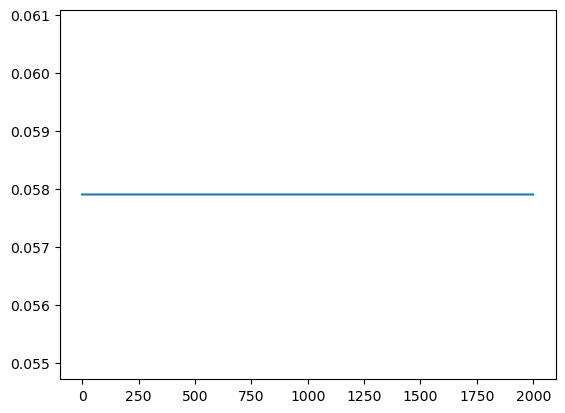

In [54]:
plt.plot(range(2000), total_loss)
plt.show()

##### 역전파(backpropagation), **미분의 연쇄법칙(chain rule)**

y_pred = ax^3 + bx^2 + cx +d
손실함수 : loss = (y_pred - y)

loss 는 파라미터(a,b,c,d)들과 직접 연관이 없음.
다만 다음과 같은 연쇄구조를 가진다 (chain)
a,b,c,d --> y_pred --> loss

- 미분 연쇄 법칙 : **"A가 B에, B가 C에 의존한다면, A의 C에 대한 변화율은 곱으로 연결된다"**는 법칙
D-loss / D-a   = [ D-loss / D-y_pred ] * [ D-y_pred / D-a ]

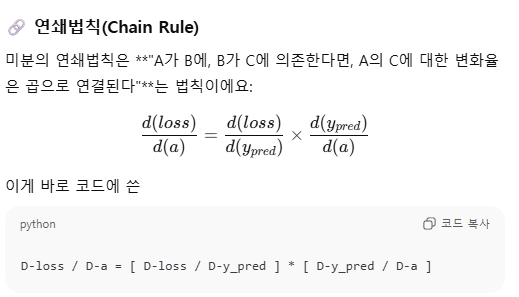

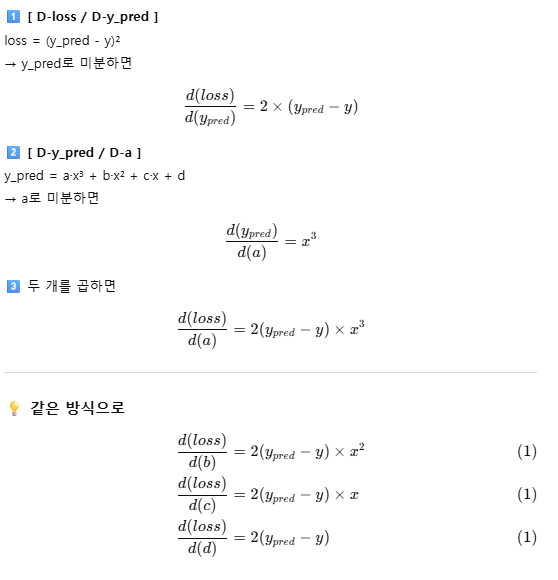

============================================================

#### 보스턴 집값 예측

In [ ]:
# 보스턴 집값 예측
import pandas as pd
import numpy as np

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]
target
data.shape # (506,13) 출력 샘플 506개, feature 13개 (컬럼)

(506, 13)

In [62]:
data.shape, target.shape

((506, 13), (506,))

In [63]:
target.reshape(-1,1).shape

(506, 1)

In [ ]:
# pytorch
# 미분을 자동으로 계산
# 계산된 미분을 optimizer를 통해 적용 : 최적화 알고리즘
import torch
import torch.nn as nn
from torch.optim.adam import Adam
# 모델 정의 : 분류, 회귀 모두 예측
model = nn.Sequential(
    nn.Linear (data.shape[1], 100), #13개의 데이터를 입력받아서 결과 100개를 예측 
    nn.ReLU(),
    nn.Linear(100,1) # 100개의 예측결과를 받아서 최종 1개를 예측
)

# 하이퍼 파라미터 정의
batch_size = 100
learning_rate = 1e-03 # 0.001 경사하강법에서 learning rate 필수

# 옵티마이저 정의
optim = Adam(model.parameters(), lr=learning_rate)


target=target.reshape(-1,1)  # loss 계산시, preds와 정답의 shape가 같아야 해서 변경해줌. data.shape, target.shape 확인.
# 학습 루프
for epoch in range(200):
    for i in range(len(data)//batch_size) :
        start = i*batch_size
        end = start + batch_size
        X = torch.FloatTensor(data[start:end])
        y = torch.FloatTensor(target[start:end])

        optim.zero_grad()
        preds = model(X)  # forward : 입력과 출력의 shape가 같아야함.
        loss = nn.MSELoss()(preds, y) # 클래스(객체)이지만, 함수처럼 쓸수 있게 설계된 객체

                            # PyTorch의 MSELoss 내부 구조 (단순화 버전)
                            # class MSELoss(nn.Module):
                            #     def __init__(self):
                            #         super().__init__()
                                
                            #     def forward(self, input, target):
                            #         return torch.mean((input - target)**2)
                                
                            #     def __call__(self, input, target):
                            #         # __call__이 호출되면 자동으로 forward를 부름!
                            #         return self.forward(input, target)
                            # 📘 그래서 이런 코드가 가능함
                            # loss_fn = nn.MSELoss()     # 객체 생성
                            # loss = loss_fn(preds, y)   # 함수처럼 호출 (내부에서 __call__ → forward 실행)




        loss.backward() #연쇄법칙을 사용해 모든 파라미터(a,b,c,d)의 기울기를 계산 / 각 파라미터의 gradient를 자동으로 계산해서 .grad 저장
        optim.step() #업데이트 / 옵티마이저가 .grad정보를 사용해서 파라미터를 갱신
    if epoch % 20 == 0:
        print (f'epoch : {epoch+1}, loss : {loss.item()}') # 에포크의 가장 마지막 배치만 출력(평균)

epoch : 1, loss : 21648.154296875
epoch : 21, loss : 52.06745910644531
epoch : 41, loss : 40.48335647583008
epoch : 61, loss : 35.9373893737793
epoch : 81, loss : 32.25990295410156
epoch : 101, loss : 28.788070678710938
epoch : 121, loss : 25.810232162475586
epoch : 141, loss : 23.861438751220703
epoch : 161, loss : 21.142637252807617
epoch : 181, loss : 18.60520362854004


<span style="font-size:11px">

#### 정리
- forward : X -> model -> preds -> loss

- backward : dloss/lpreds 계산해서 각 선형층의 파라미터(가중치, 편향)로 전파
    - loss.backward() 호출되어 pytorch에 autograd가 연쇄법칙(chain rule)을 이용해서 
        각 파라미터의 .grad를 채움
    - optim.step() : .grad를 읽어서 파라미터를 갱신

- ReLU (활성화 함수) : max (0,z)
    - z가 음수이면 0, 양수면 그대로 전달
    - backward 
        z > 0 : dReLU(z)/dz = 1
        z <=0 : dReLU(z)/dz = 0
    - 장점 
        - 비선형을 제공해서 계산이 간단해진다
        - 기울기 소실이 발생되는 sigmoid, tanh 보다 유리함
    - 음수이면 0이기때문에, 일부 뉴런이 비활성화되어 표현이 희소해짐 --> LeekyReLU 개선

- Adam : 옵티마이저
    - 모멘텀과 스케일 조정 두가지 방법을 결합
    - 적응적 학습률 : 파라미터별로 학습률을 조정 -> 초기값 안정적
    - 빠른 수렴 : SGD 보다 빠름
    - 튜닝이 거의 필요 없음. 기본 파라미터가 lr=0.001도 좋은 성능
    - 단점 : 과적합이 다른 최적화 모델에 비해 발생하기 쉬운 구조


<span style="font-size:11px">

#### 모델이 학습할 때, 파마리터(가중치)를 얼아마, 어떤 방향으로 바꿀지 정하는 방법

##### 옵티마이저
- 옵티마이저: 모델 파라미터 손실이 줄어들게 갱신하는 역할
    - p_t: 현재 파라미터
    - n: 학습률 (얼마나 크게 바꿀지)
    - gt: 현재 그래디언트 (얼마나 틀렸는지, 어떤 방향으로 바꿔야하는지)

    p_t + 1 = p_t - n * gt
    
- 단점:
    - 기울기가 들쑥날쑥 (노이즈에 약함)
    - 모든 파라미터가 같은 학습률을 적용 (비효율적)
    - --> 모멘텀, 스케일 조정

- 모멘텀 : 
    - 이전 기울기의 방향을 "기억"해서 관성처럼 부드럽게 이동하는 기법
    - vt : 누적된 속도 또는 1차 모멘트
    - gt : 현재 그래디언트
    - b1 : 모멘텀의 개수 (보통 0.9)
    - n : 학습률
    - vt = b1*vt-1 + (1-b1)gt
            pt+1 = pt - n*vt
    - 시점
        - t : 1  ----> 단순히 g1을 따라감
        - t : 2  ----> 이전 속도 v1의 일부를 남겨서 새로운 기울기에 더함
        - t ---> 무한대  여러 스텝동안 방향이 일정하면 점점 가속되어 빠르게 수렴
        - 기울기가 변해도 관성때문에 부드럽게 움직임

- 스케일 조정 (AdaGrad, RMSProp)
    - 파라미터의 기울기의 크기를 고려해서 학습률을 자동으로 조정
    - 과거 파라미터의 크기를 추척해서 큰 변동이 있었던 파라미터는 작게, 작은 변동은 크게 이동

- Adam (요즘 거의 기본값) : 모멘텀 + 스케일 조정 ---> 하이브리드 방식
    - step1 : 모멘텀 (방향기억)
    - step2 : 스케일 조정 (RMSProp 각 파라미터별 학습 자동 조절))
    - stpe3 : bias 보정 (초기단계에서 불균형 보정) / 초기, 스텝에서는 m,v = 0 보정
    - step4 : 최종 업데이트 :  모멘텀으로 얻은 방향 + 스케일 조정된 학습률 이동


| Optimizer           | 개념 설명                                 | 특징 / 장단점                          |
|----------------------|-------------------------------------------|----------------------------------------|
| **SGD**              | 단순한 그래디언트                         | 진동 심함, 수렴 느림                   |
| **Momentum**         | 과거 방향의 관성을 사용                   | 진동 완화, 빠른 수렴                   |
| **RMSProp / AdaGrad**| 그래디언트 제곱의 평균으로 스케일 조정    | 파라미터별 자동 학습률 조정            |
| **Adam**             | 모멘텀 + RMSProp 결합                     | 기본 설정으로도 훌륭한 성능            |


https://wikidocs.net/152765

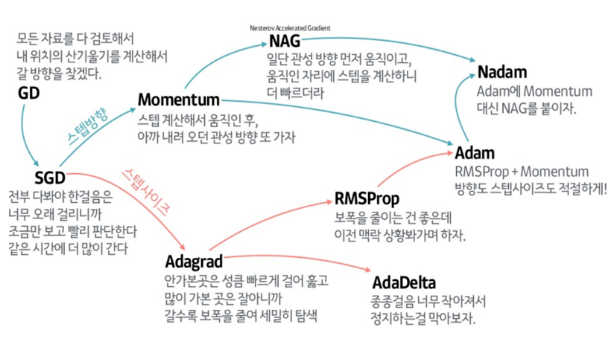

In [69]:
# 모델 성능 평가 : 예측
print(data.shape, target.shape)
data[0, :].shape
# predict = model(torch.FloatTensor(data[0])).item()
# predict, target[0].item()
predict = model(torch.FloatTensor(data)).detach().numpy() # --> numpy로 변경
predict.shape, target.shape



(506, 13) (506, 1)


((506, 1), (506, 1))

In [70]:
# 결정계수
from sklearn.metrics import r2_score
r2_score(target, predict)

0.6064562726867255

In [ ]:
# 머신러닝 비교 평가
# RandomForest 